In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB


from sklearn.model_selection import train_test_split #split
from sklearn.metrics import accuracy_score #metrics


In [27]:
ds = pd.read_csv('bank-full.csv')

In [28]:
ds.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,Target
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [30]:
#Number of Rows 
print(" total number of {rows} rows.".format(rows = len(ds)))

 total number of 45211 rows.


In [31]:
#Find any missing values
missing_values = ds.isnull().mean()*100

missing_values.sum()

0.0

In [ ]:
#Observation :No Missing Rows 

In [32]:
ds.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [ ]:
# Observations
# Mean age is 40 yrs and max is 95 years
# Mean balance 1362 , standard devaition is very high number balance is distrubuted heavily
# As suggested in the Project description  we have drop the duration column 

In [33]:
ds['Target'].value_counts()

no     39922
yes     5289
Name: Target, dtype: int64

In [34]:
#Observations 
#More number of people have not opened > people who opened  

In [35]:
ds.shape

(45211, 17)

In [36]:
ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
age          45211 non-null int64
job          45211 non-null object
marital      45211 non-null object
education    45211 non-null object
default      45211 non-null object
balance      45211 non-null int64
housing      45211 non-null object
loan         45211 non-null object
contact      45211 non-null object
day          45211 non-null int64
month        45211 non-null object
duration     45211 non-null int64
campaign     45211 non-null int64
pdays        45211 non-null int64
previous     45211 non-null int64
poutcome     45211 non-null object
Target       45211 non-null object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [37]:
# Obseravations 
# Mix of Categorical and Numerical Values 
# we need to convert these catergorical to numerical ones 

In [38]:
# Univariate Analysis

In [39]:
# Let us start with analysis of categorical values
    

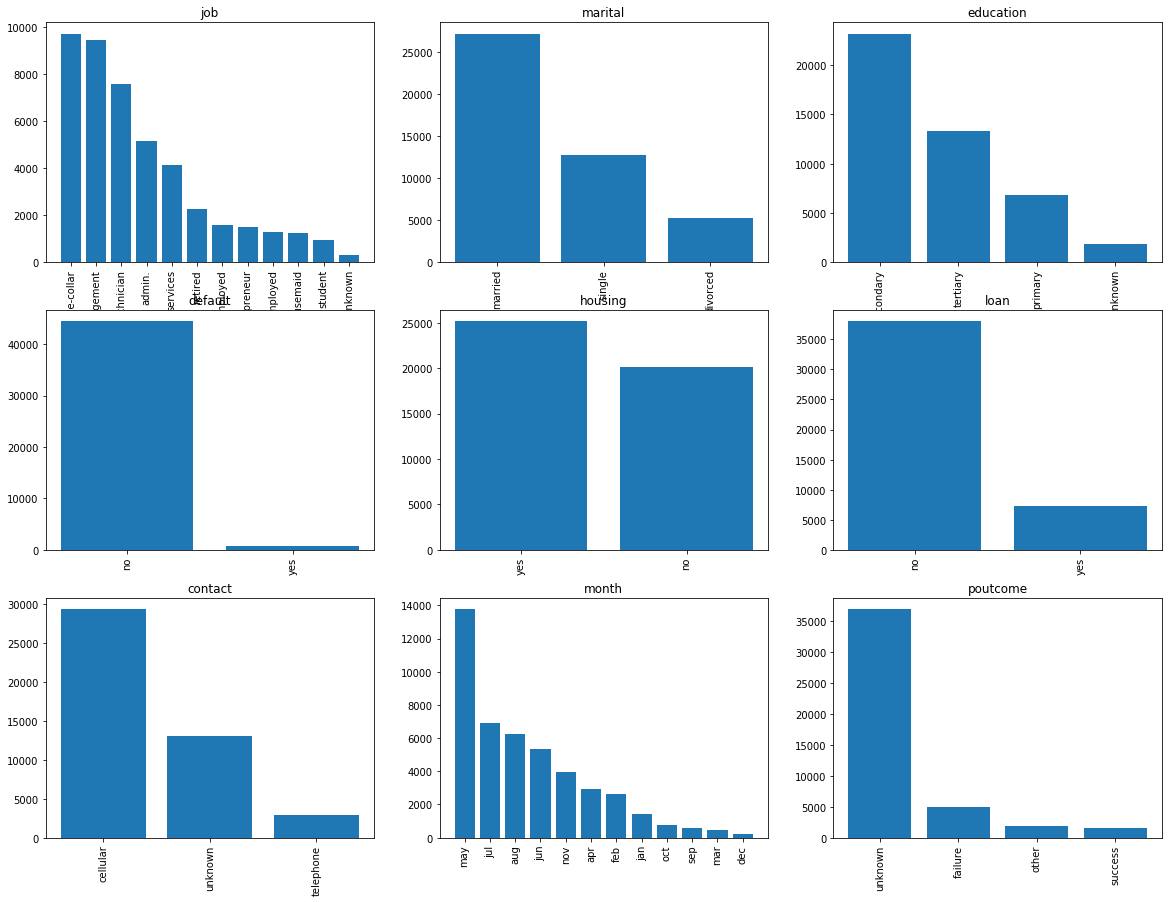

In [44]:
cat_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month','poutcome']

fig, axs = plt.subplots(3, 3, sharex=False, sharey=False, figsize=(20, 15))

counter = 0
for cat_column in cat_cols:
    value_counts = ds[cat_column].value_counts()
    
    trace_x = counter // 3
    trace_y = counter % 3
    x_pos = np.arange(0, len(value_counts))
    
    axs[trace_x, trace_y].bar(x_pos, value_counts.values, tick_label = value_counts.index)
    
    axs[trace_x, trace_y].set_title(cat_column)
    
    for tick in axs[trace_x, trace_y].get_xticklabels():
        tick.set_rotation(90)
    
    counter += 1

plt.show()

In [ ]:
# Obseravtions

#1.May to November is seen more prevalent in terms of months.
#2.Unknown seems to be the highest in poutcome 
#

In [ ]:
#  Numerical  values

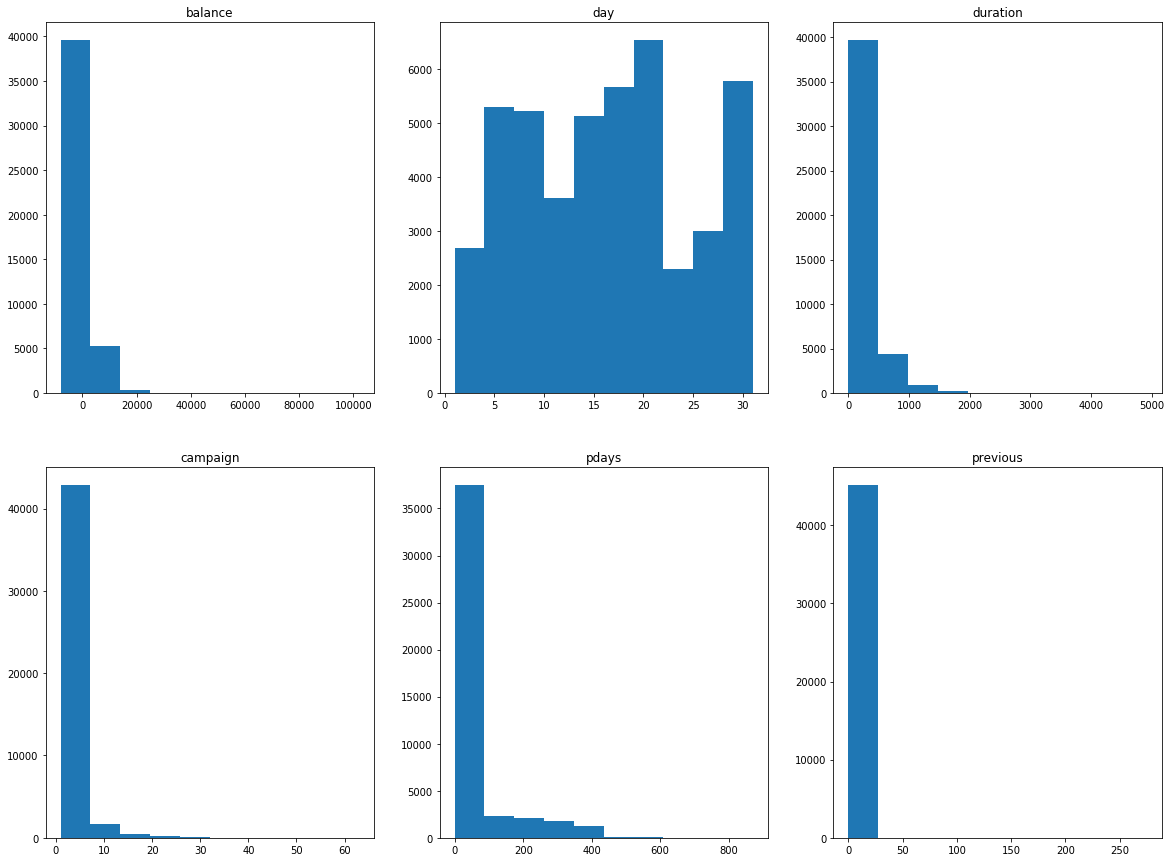

In [40]:
num_columns = ['balance', 'day','duration', 'campaign', 'pdays', 'previous']

fig, axs = plt.subplots(2, 3, sharex=False, sharey=False, figsize=(20, 15))

counter = 0
for num_column in num_columns:
    
    trace_x = counter // 3
    trace_y = counter % 3
    
    axs[trace_x, trace_y].hist(ds[num_column])
    
    axs[trace_x, trace_y].set_title(num_column)
    
    counter += 1

plt.show()

In [ ]:
# Obseverations of Numerical Values 
#1. Numerical values previous,pdays and campaign has outliers could be noisy values

In [41]:
ds[['pdays', 'campaign', 'previous']].describe()

,pdays,campaign,previous
count,45211.000000,45211.000000,45211.000000
mean,40.197828,2.763841,0.580323
std,100.128746,3.098021,2.303441
min,-1.000000,1.000000,0.000000
25%,-1.000000,1.000000,0.000000
50%,-1.000000,2.000000,0.000000
75%,-1.000000,3.000000,0.000000
max,871.000000,63.000000,275.000000


In [ ]:
# Observation 
# Outliers seen in the pdays,previous and campaign

In [ ]:
# Observations on pdays
# 1. -1 possibly means that the client wasn't contacted before or stands for missing data.
# 50 % of the data is in -1 , and standard devaition is very high this means this is a useless column drop this column while cleaning data 
#

In [ ]:
#Observations on previous 
# min,percentile are all 0s we need to impute average while data cleansing

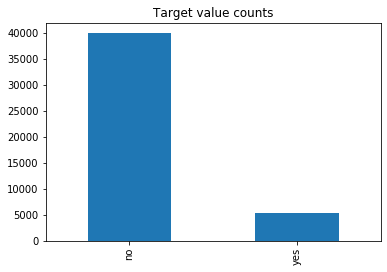

In [51]:
value_counts = ds['Target'].value_counts()

value_counts.plot.bar(title = 'Target value counts')

In [ ]:
# Obseravtions 
# Skewed target data , we have to use Recall not accuracy


In [ ]:
# Multi variate Analysis
    

In [ ]:
# Type of job versus the Targets

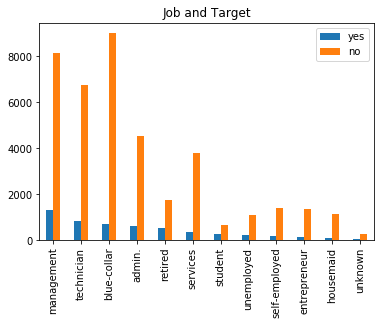

In [54]:
j_dframe = pd.DataFrame()

j_dframe['yes'] = ds[ds['Target'] == 'yes']['job'].value_counts()
j_dframe['no'] = ds[ds['Target'] == 'no']['job'].value_counts()

j_dframe.plot.bar(title = 'Job and Target')

In [ ]:
# Observation
# Blue collar jobs,technicians,management ,services ,enterprenuers are less likely targets


In [ ]:
# Martial status verus Target

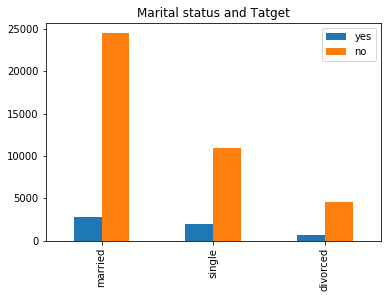

In [56]:
#marital status and Target
j_df = pd.DataFrame()

j_df['yes'] = ds[ds['Target'] == 'yes']['marital'].value_counts()
j_df['no'] = ds[ds['Target'] == 'no']['marital'].value_counts()

j_df.plot.bar(title = 'Marital status and Tatget')

In [ ]:
# Observations 
#1. Married persons are less likely targets
#2. Divorcess may have lost money , there yes are also low .Less likely targets

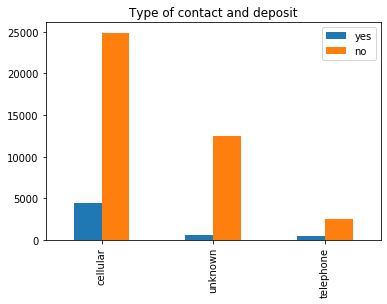

In [59]:
#type of contact and Target
j_df = pd.DataFrame()

j_df['yes'] = ds[ds['Target'] == 'yes']['contact'].value_counts()
j_df['no'] = ds[ds['Target'] == 'no']['contact'].value_counts()

j_df.plot.bar(title = 'Type of contact and deposit')

In [ ]:
# Observations 
#1. Cellular phone users are less likey targets



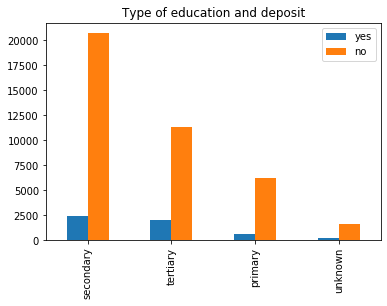

In [60]:
#type of education and Target
j_df = pd.DataFrame()

j_df['yes'] = ds[ds['Target'] == 'yes']['education'].value_counts()
j_df['no'] = ds[ds['Target'] == 'no']['education'].value_counts()

j_df.plot.bar(title = 'Type of education and deposit')

In [ ]:
# Observations 
#1. Level of ediucation is a significant decider
